In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rapid = pd.read_parquet('../data/processed/rapid/top_50_rapid.parquet')
bullet = pd.read_parquet('../data/processed/bullet/top_50_bullet.parquet')


### 1. Durante a coleta dos dados (Partidas dos Top 50 jogadores) percebi que as partidas de Bullet rapidamente eram coletadas, enquanto as de Rapid demoravam mais, precisavam ir mais longe no tempo para conseguir todas as 200 partidas

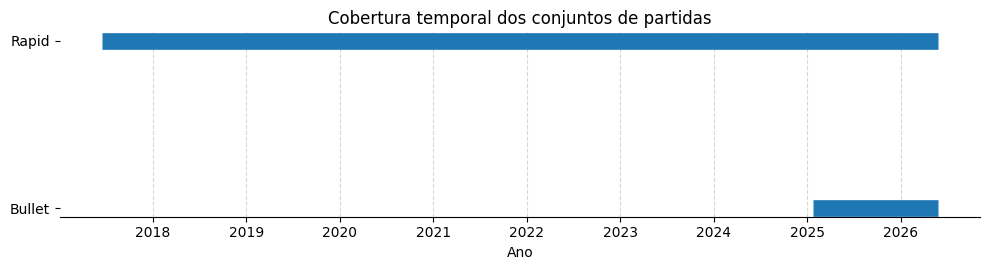

In [ ]:
# Datas inicial e final de cada conjunto
rapid_inicio = rapid["end_time"].min()
rapid_fim = rapid["end_time"].max()

bullet_inicio = bullet["end_time"].min()
bullet_fim = bullet["end_time"].max()

# Criar figura
fig, ax = plt.subplots(figsize=(10, 2.8))

# Linha Rapid
ax.hlines(
    y=1,
    xmin=rapid_inicio,
    xmax=rapid_fim,
    linewidth=12,
    label="Rapid"
)

# Linha Bullet
ax.hlines(
    y=0,
    xmin=bullet_inicio,
    xmax=bullet_fim,
    linewidth=12,
    label="Bullet"
)

# eixo Y
ax.set_yticks([1, 0])
ax.set_yticklabels(["Rapid", "Bullet"])

# eixo X
ax.set_xlabel("Ano")
ax.set_title("Cobertura temporal dos conjuntos de partidas")
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Remover bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

Com esse gráfico é perceptível que a coleta das partidas de Bullet, tiveram uma faixa de ~1 ano para conseguir as 200 partidas

Já as partidas de Rapid, preciram ir até 2017, para coletar todas as partidas

---

O que é um bom indicativo de que os Top Players do mundo, constumam jogar muito mais partidas Bullet do que Rapid

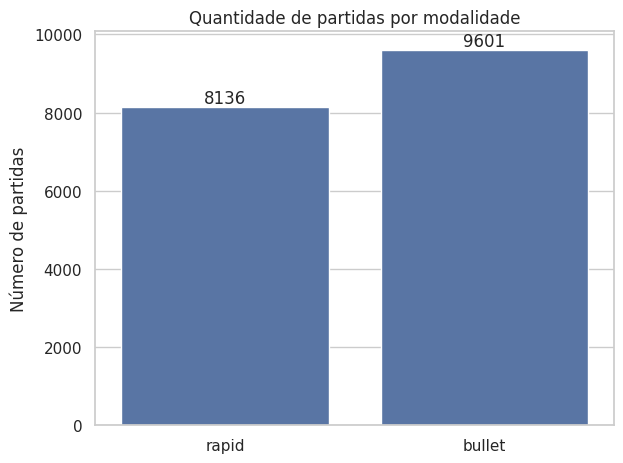

In [53]:
# DF temporário para a contagem das partidas
df_contagem = pd.DataFrame(
    {
        "tipo": ["rapid", "bullet"],
        "qtde_partidas": [len(rapid), len(bullet)]
    }
)

# Criar figura
ax = sns.barplot(
    data=df_contagem,
    x="tipo",
    y="qtde_partidas"
)

ax.set_title("Quantidade de partidas por modalidade")
ax.set_xlabel("")
ax.set_ylabel("Número de partidas")

# Mostrar o valor acima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

Nesse gráfico de barras, da para ver claramente essa diferença no valor bruto. 

- Rapid com 8136 partidas, de um total esperado de 10000.
    
    Ou seja, mesmo buscando partidas em um intervalo de ~9 anos, alguns players não tiveram 200 partidas na conta

- Bullet com 9601 partidas, de um total esperado de 10000.

    Se aproximou do valor total, mas em alguns casos também não alcançou as 200 partidas totais por jogadores